**Isolation Forest for Anomaly Detection**

Isolation Forest detects anomalies by isolating instances rather than profiling normal data points. Because anomalies are "few and different," they require fewer random recursive splits to be isolated in a tree compared to normal points.

---

**Core Mathematical Formula**

The anomaly score $s(x, n)$ for an instance $x$ given a dataset of size $n$ is defined as:

$$\text{Anomaly Score}(x) = 2^{-\frac{E(h(x))}{c(n)}}$$

* **$x$**: A single sample or observation being evaluated.
* **$n$**: Total number of samples / size of the dataset (or subsample size used to construct the trees).
* **$h(x)$**: Path length, measured as the number of edges $x$ traverses from the root node to a terminating leaf node in an isolation tree (iTree).
* **$E(h(x))$**: Expected (average) path length of $x$ across an ensemble of isolation trees.
* **$c(n)$**: Average path length of unsuccessful searches in a Binary Search Tree (BST) for a dataset of size $n$, used as a normalization factor:

$$c(n) = 2\left(\ln(n - 1) + 0.5772156649\right) - \frac{2(n - 1)}{n}$$



---

**Interpreting the Anomaly Score $s(x)$**

The score ranges between $0$ and $1$:

* **Score close to $1$ ($\approx 1$):** Indicates an **outlier / anomaly**. The average path length $E(h(x))$ is very short, meaning the point gets isolated near the root with very few splits.
* **Score around $0.5$ ($\approx 0.5$):** Indicates a **borderline case**. The point does not exhibit distinct anomaly characteristics; the entire dataset may lack clearly distinct anomalies.
* **Score close to $0$ ($\approx 0$):** Indicates a **normal / inlier point**. The path length is long, requiring many splits to isolate, typical of dense, clustered data.



In [4]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df= pd.read_csv("thyroid_dataset.csv")


In [7]:
X=df.drop("Outlier_label",axis=1)
y=df["Outlier_label"]

In [8]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [21]:
from sklearn.ensemble import IsolationForest
clf=IsolationForest(
    n_estimators=200,
    contamination=0.0349,
    random_state=42
)


In [22]:
labels=clf.fit_predict(X_scaled)

In [23]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

Text(0, 0.5, 'PC2')

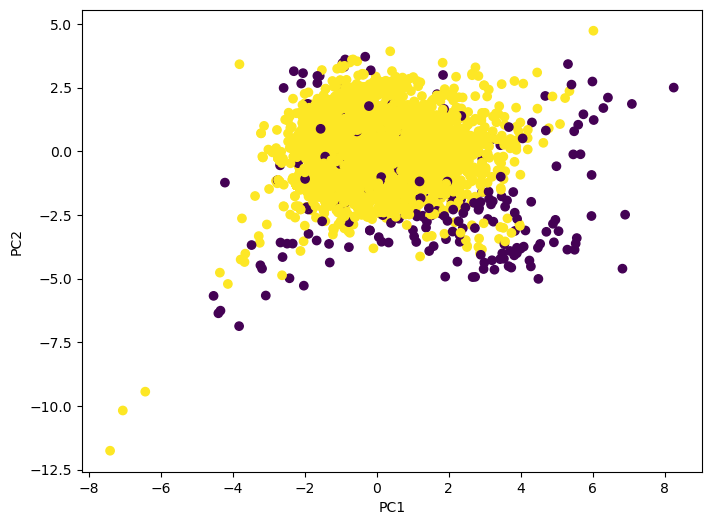

In [24]:

plt.figure(figsize=(8,6))
plt.scatter(
X_pca[:,
0],
X_pca[:, 1],c=labels
)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [25]:
import numpy as np
n_outliers=np.sum(labels==-1)
print(n_outliers)

242


###LOF

In [16]:
from sklearn.neighbors import LocalOutlierFactor

In [17]:
nieghbs=LocalOutlierFactor()
lables=nieghbs.fit_predict(X_scaled)

Text(0, 0.5, 'PC2')

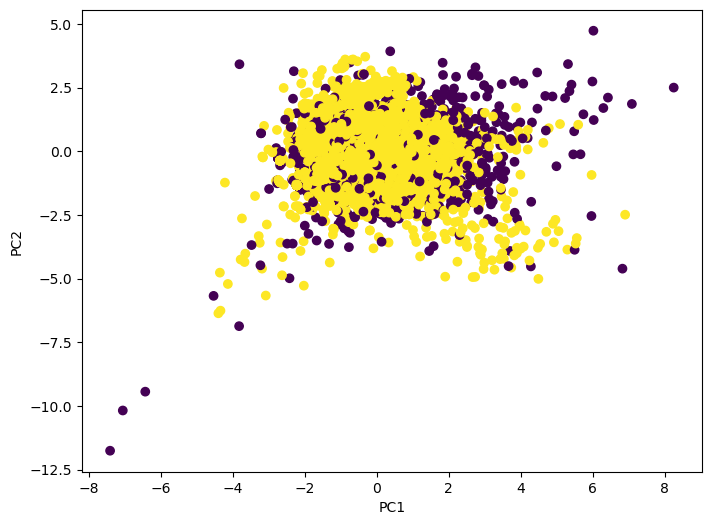

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(
X_pca[:,
0],
X_pca[:, 1],c=lables
)
plt.xlabel("PC1")
plt.ylabel("PC2")